## TSPN

### import model

In [1]:
import argparse
from model.TSPN import Transparent_Signal_Processing_Network
from trainer.trainer_basic import Basic_plmodel

import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
parser = argparse.ArgumentParser(description='TSPN')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_basic.yaml',help='The directory of the configuration file')
# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
signal_processing_modules, feature_extractor_modules = config_network(configs,args)
MODEL_DICT = {'TSPN': lambda args: Transparent_Signal_Processing_Network(signal_processing_modules, feature_extractor_modules,args)}
model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/tspn.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)

Running experiment: model_TSPNtime08-21-02-31_datasetSEU_010_Basic_it0
# build signal processing layers
# build feature extractor layers
# build classifier


<All keys matched successfully>

### plot signal function

In [2]:
def get_TSPN_signal(model, signal,i):
    with torch.no_grad():
        for idx, layer in enumerate(model.signal_processing_layers):
            signal = layer(signal)
            if idx == i:
                break
    return signal

def compute_frequency_domain(signal):
    fft_values = torch.fft.rfft(signal)
    fft_values = fft_values.detach().cpu().numpy()
    # 去除直流项
    fft_values[0] = 0
    return np.abs(fft_values)

def plot_signal(signal, savename):
    plt.rcParams['font.family'] = 'Times New Roman'
    fig, axs = plt.subplots(2, 2, figsize=(16, 4))

    for i in range(2):
        signal_time = F.normalize(signal[i,:],dim=0)
        t = np.linspace(0, 4096/5120, signal_time.shape[0])
        signal_time = signal_time.detach().cpu().numpy()
        signal_fft = compute_frequency_domain(signal[i,:])
        axs[i,0].plot(t, signal_time,linewidth=1.0 ,c='#5291B2')
        axs[i,1].plot(signal_fft,linewidth=1.0 ,c='#283D7E')
        if i == 1:
            axs[i,0].set_xlabel('Time (s)', fontsize=18)
            axs[i,1].set_xlabel('Frequency (Hz)', fontsize=18)
    # fig.tight_layout()
    plt.savefig('save/figure/seu/signal/' + savename)
    # plt.show()

def plot_ori_signal(number, signal, savename):
    plt.rcParams['font.family'] = 'Times New Roman'
    test_signal = signal[number,:,:].unsqueeze(0)
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 4))
    for i in range(2):
        signal_time = F.normalize(test_signal[0,:,i],dim=0)
        t = np.linspace(0, 4096/5120, signal_time.shape[0])
        signal_time = signal_time.detach().cpu().numpy()
        signal_fft = compute_frequency_domain(test_signal[0,:,i])
        axs[i,0].plot(t, signal_time,linewidth=0.5 ,c='#5291B2')
        axs[i,1].plot(signal_fft,linewidth=0.5 ,c='#283D7E')
        if i == 1:
            axs[i,0].set_xlabel('Time (s)', fontsize=18)
            axs[i,1].set_xlabel('Frequency (Hz)', fontsize=18)
    # fig.tight_layout()
    # plt.show()
    plt.savefig('save/figure/seu/signal/' + savename + '_original.svg')

### data & plot_signal

(1270, 4096, 2)
{np.float64(0.0): 253, np.float64(1.0): 507, np.float64(2.0): 761, np.float64(3.0): 1015, np.float64(4.0): 1269}
torch.Size([12, 4096])
torch.Size([12, 4096])
torch.Size([12, 4096])
torch.Size([12, 4096])
torch.Size([12, 4096])


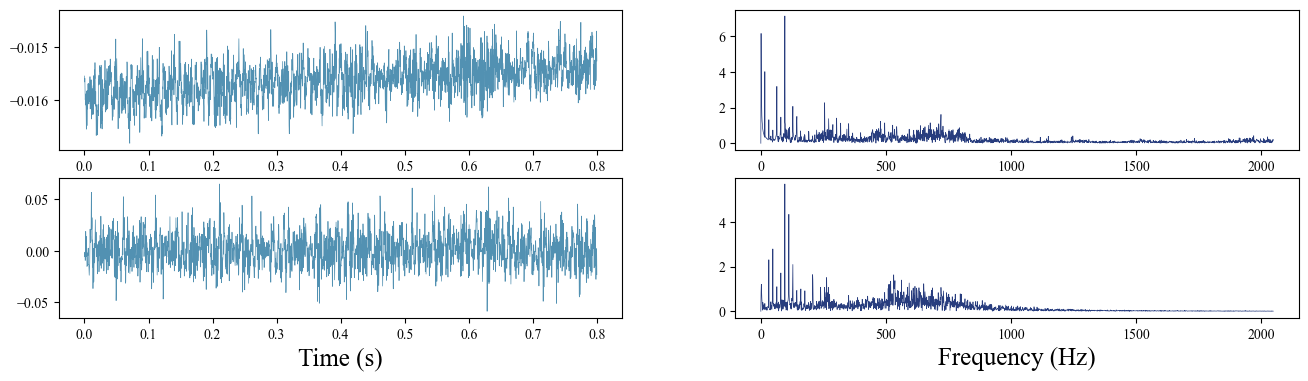

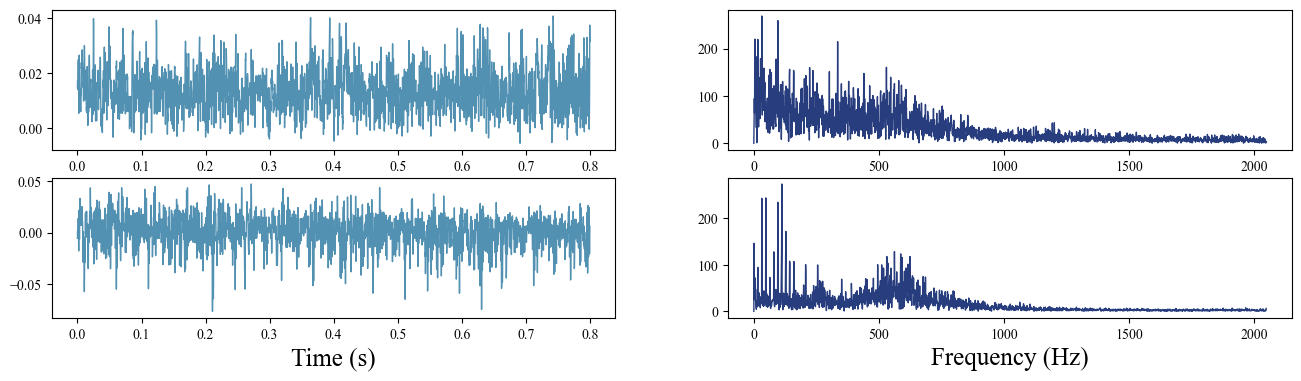

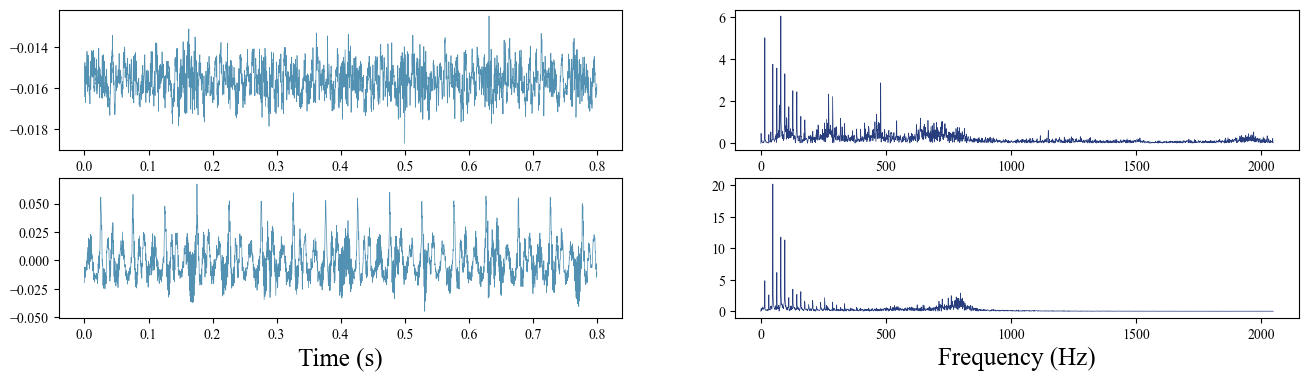

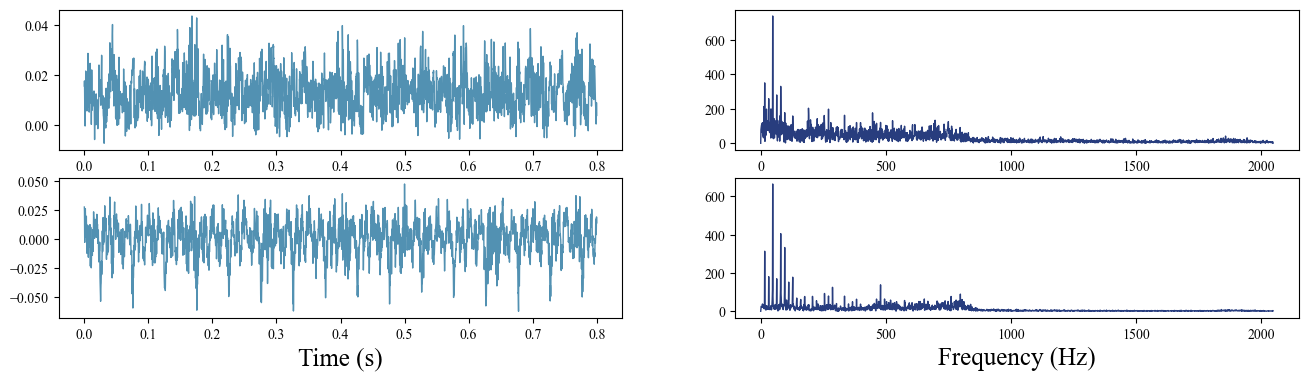

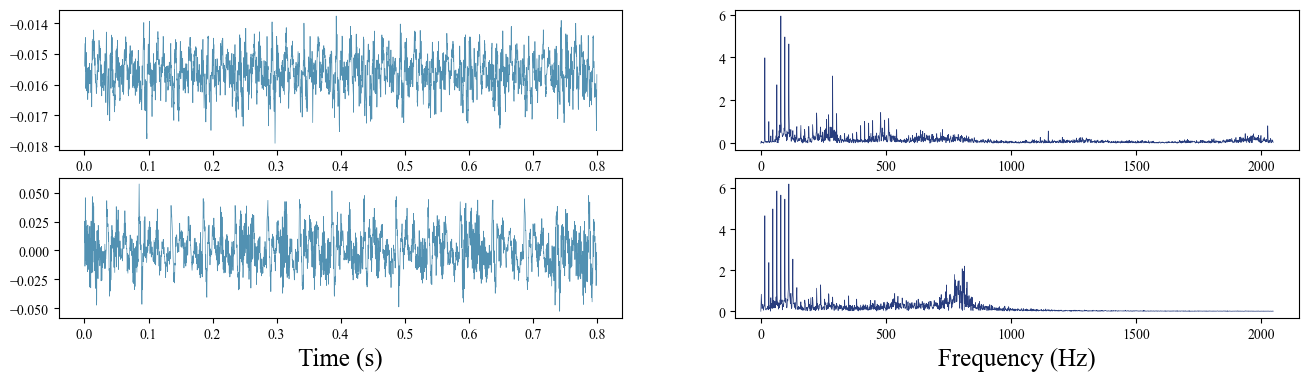

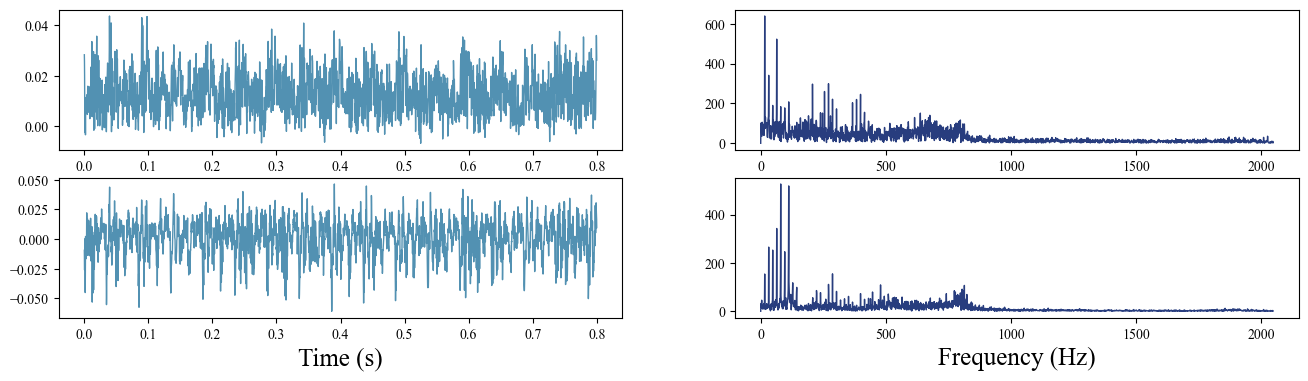

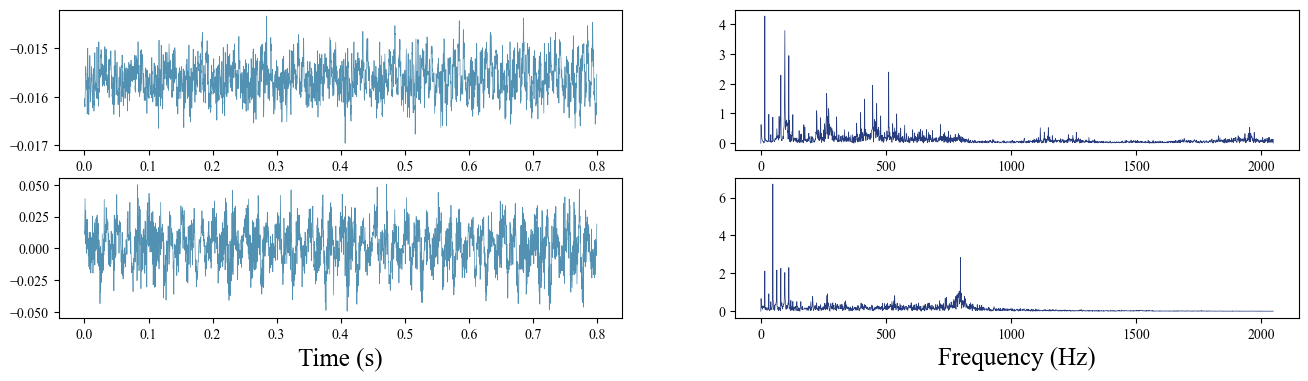

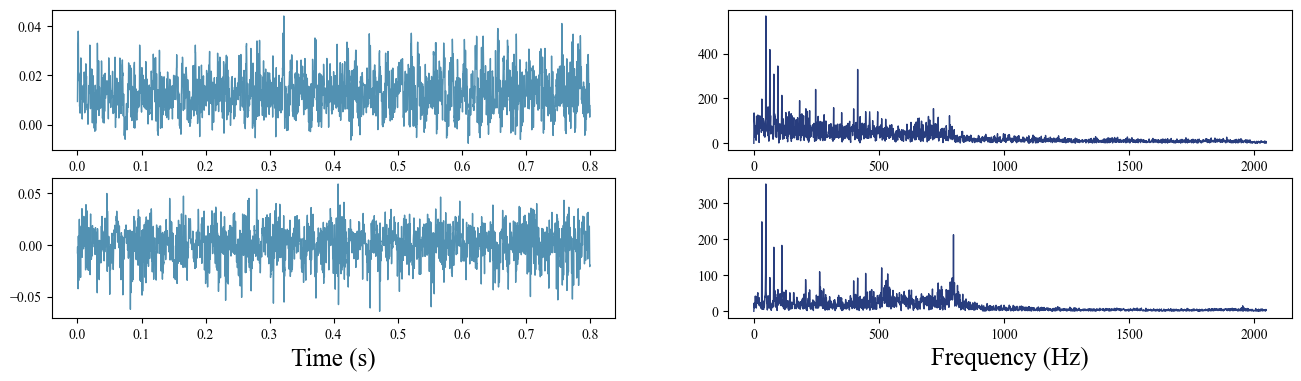

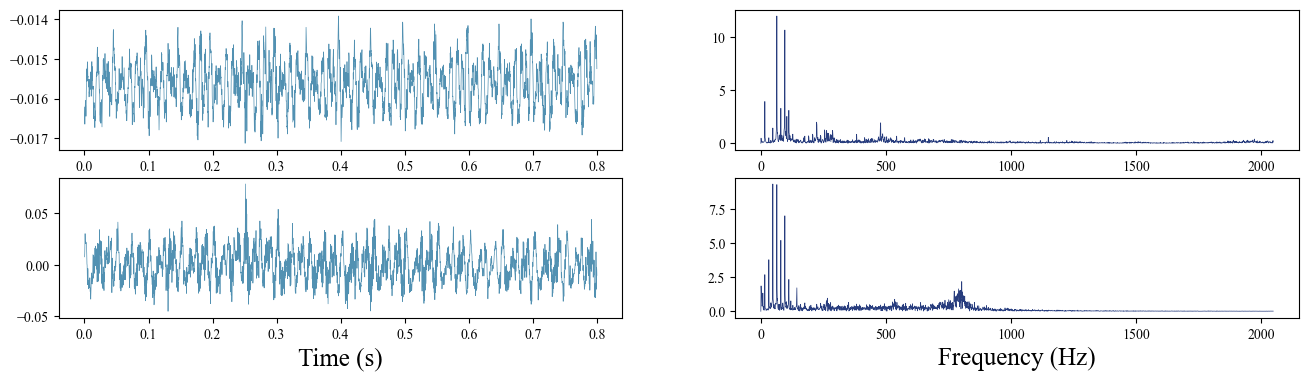

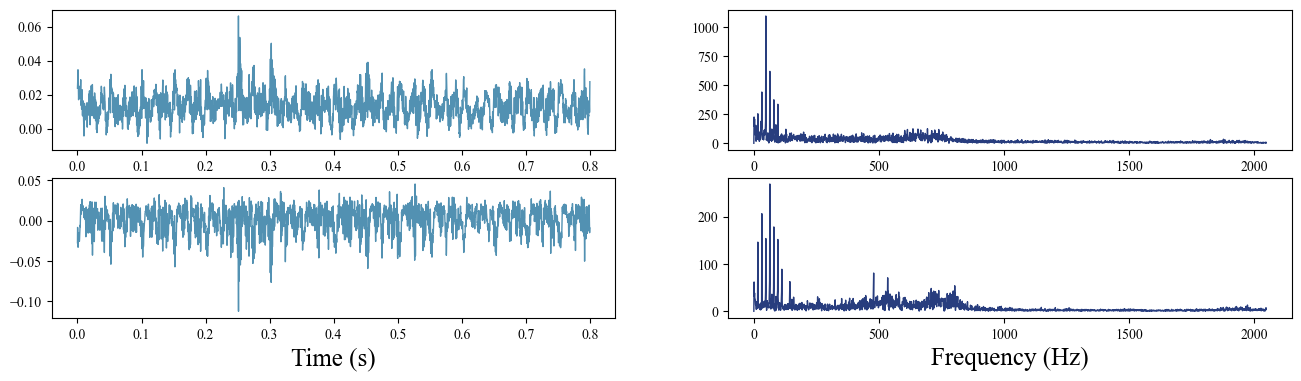

In [3]:
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
test_signal = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_label = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
# 确定每种类别的结束索引
end_indices = {label: idx for idx, label in enumerate(test_label)}
print(end_indices)
test_signal = torch.from_numpy(test_signal).cuda().float()
signal_num_list = [25, 260, 510, 770, 1070]
for signal_num in signal_num_list:
    torch.cuda.empty_cache()
    plot_ori_signal(signal_num, test_signal, fault_type_list[signal_num//253])
    output_signal = get_TSPN_signal(model.network.cuda(), test_signal, 3)[signal_num,:,:]
    output_signal = output_signal.T
    plot_signal(output_signal, fault_type_list[signal_num//253] + '_after.svg')
    print(output_signal.shape)

### weights

第1层信号贡献可视化：


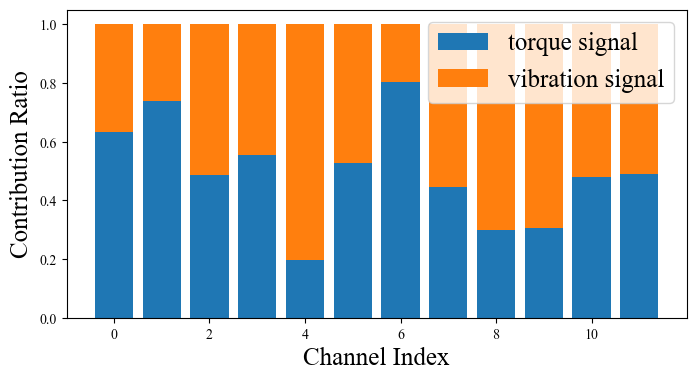

第2层信号贡献可视化：


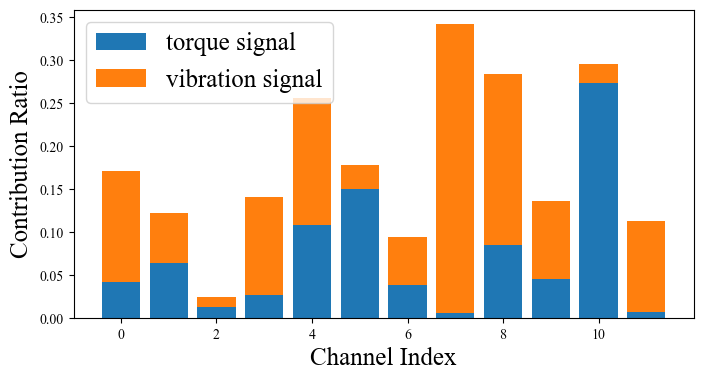

第3层信号贡献可视化：


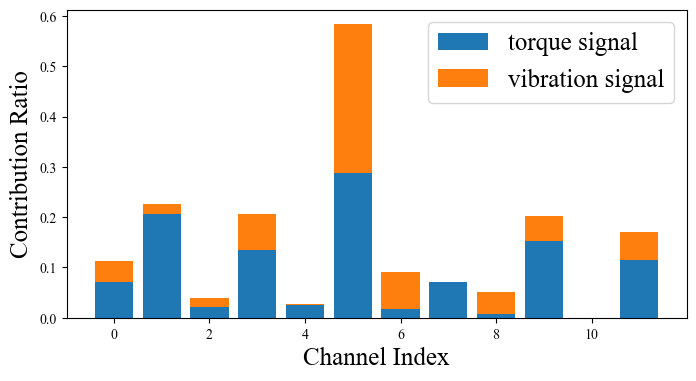

第4层信号贡献可视化：


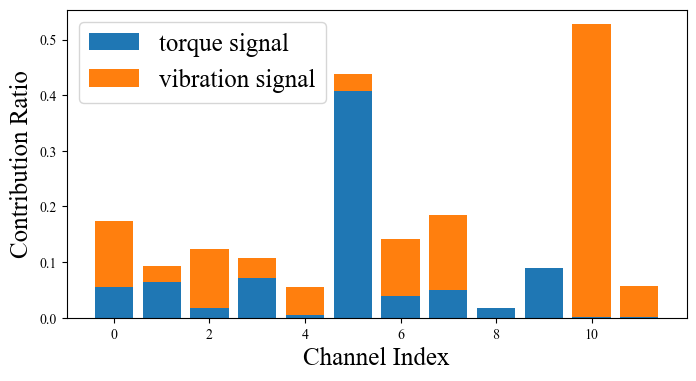

In [4]:
def plot_weight(weight, name):
    plt.imshow(weight, cmap='Oranges')
    plt.xlabel('Input Channels', fontsize=18)
    plt.ylabel('Output Channels', fontsize=18)
    plt.colorbar()
    plt.savefig('save/figure/seu/weight/'+ f'{name}.svg')
    plt.clf()

def visualize_signal_contribution(layer, savename):
    main_weight = layer.weight_connection.weight.data.cpu().numpy()
    skip_weight = layer.skip_connection.weight.data.cpu().numpy()
    total_weight = main_weight + skip_weight
    weight_norm = np.abs(total_weight) / np.abs(total_weight).sum(axis=1, keepdims=True)
    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(weight_norm.shape[0]), weight_norm[:, 0], label='torque signal')
    plt.bar(np.arange(weight_norm.shape[0]), weight_norm[:, 1], bottom=weight_norm[:, 0], label='vibration signal')
    plt.xlabel('Channel Index', fontsize=18)
    plt.ylabel('Contribution Ratio', fontsize=18)
    plt.legend(fontsize=18)
    # plt.title('Total Contribution of Torque and Vibration Signals to Output Features')
    plt.savefig('save/figure/seu/weight/' + 'contribution_layer_' + savename + '.svg')
    plt.show()

for i in range(4):
    # weight_sol = model.network.signal_processing_layers[i].weight_connection.weight
    # weight_sol = weight_sol.detach().cpu().numpy()
    # plot_weight(weight_sol, 'weight_sol_' + str(i))
    # weight_skip_connect = model.network.signal_processing_layers[i].skip_connection.weight
    # weight_skip_connect = weight_skip_connect.detach().cpu().numpy()
    # plot_weight(weight_skip_connect, 'weight_skip_connect_' + str(i))
    layer = model.network.signal_processing_layers[i]
    print(f"第{i+1}层信号贡献可视化：")
    visualize_signal_contribution(layer, str(i))

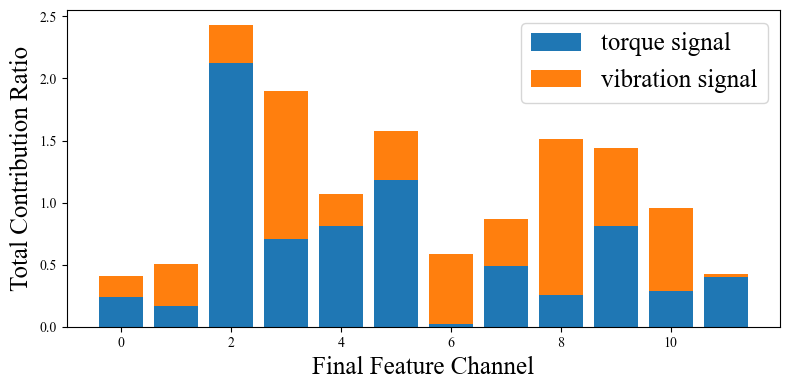

In [5]:
def get_total_contribution(model):
    weights = []
    for i, layer in enumerate(model.signal_processing_layers):
        main_weight = layer.weight_connection.weight.data.cpu().numpy()
        skip_weight = layer.skip_connection.weight.data.cpu().numpy()
        total_weight = main_weight + skip_weight
        weights.append(total_weight)
    W_total = weights[3] @ weights[2] @ weights[1] @ weights[0]
    return np.abs(W_total)

def plot_total_contribution(W_norm):
    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(W_norm.shape[0]), W_norm[:, 0], label='torque signal')
    plt.bar(np.arange(W_norm.shape[0]), W_norm[:, 1], bottom=W_norm[:, 0], label='vibration signal')
    plt.xlabel('Final Feature Channel', fontsize=18)
    plt.ylabel('Total Contribution Ratio', fontsize=18)
    plt.legend(fontsize=18)
    # plt.title('Contribution of Torque and Vibration Signals to Final Features')
    plt.tight_layout()
    # plt.show()
    plt.savefig('save/figure/seu/weight/' + 'total_contribution.svg')
W_norm = get_total_contribution(model.network)
plot_total_contribution(W_norm)

### rader plot

(1270, 13)
(5, 13)
(5, 13)


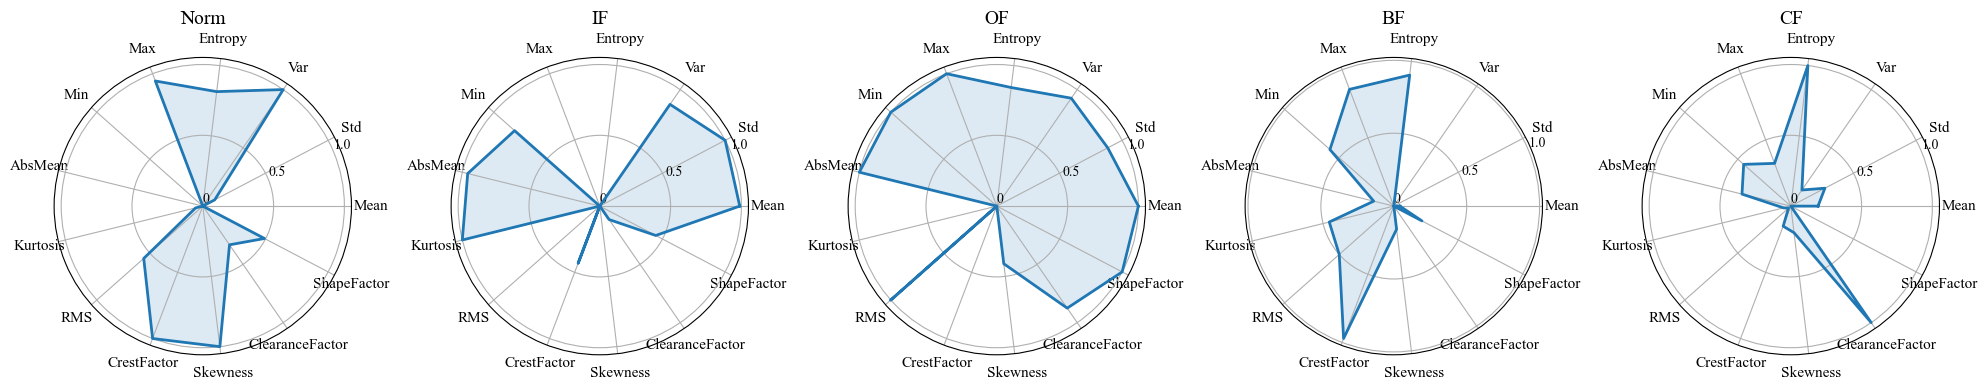

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def extract_eaff_feature(model, test_signal):
    # 前向传播，获得所有样本的最终特征向量 F
    with torch.no_grad():
        for layer in model.signal_processing_layers:
            test_signal = layer(test_signal)
        # 特征提取层输出 shape: [样本数, 特征数]
        F = model.feature_extractor_layers(test_signal)  # [N, 13]
    return F.detach().cpu().numpy()

def aggregate_by_class(F, labels, num_classes=5):
    # 按类别聚合，计算每类的均值特征
    mean_features = []
    for i in range(num_classes):
        class_features = F[labels == i]  # shape: [样本数, 13]
        mean_feat = class_features.mean(axis=0)  # shape: [13]
        mean_features.append(mean_feat)
    return np.array(mean_features)

def normalize_features(mean_features):
    # 对每个特征轴归一化到[0,1]
    min_vals = mean_features.min(axis=0)
    max_vals = mean_features.max(axis=0)
    normed = (mean_features - min_vals) / (max_vals - min_vals + 1e-8)
    return normed

def plot_radar_subplots(normed_features, feature_names, fault_type_list):
    plt.rcParams['font.family'] = 'Times New Roman'
    num_classes = len(fault_type_list)
    num_features = len(feature_names)
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]  # 闭合

    fig, axs = plt.subplots(1, num_classes, subplot_kw=dict(polar=True), figsize=(4*num_classes, 5))
    if num_classes == 1:
        axs = [axs]
    for i, ax in enumerate(axs):
        data = normed_features[i].tolist()
        data += data[:1]
        ax.plot(angles, data, color='#1f77b4', linewidth=2)
        ax.fill(angles, data, color='#1f77b4', alpha=0.15)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feature_names, fontsize=11)
        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(['0', '0.5', '1.0'], fontsize=10)
        ax.set_title(fault_type_list[i], fontsize=14)
    plt.tight_layout()
    plt.savefig('save/figure/seu/feature/fault_signature_radar_subplots.svg')
    plt.show()

# 主流程
feature_names = ['Mean', 'Std', 'Var', 'Entropy','Max', 'Min', 'AbsMean', 'Kurtosis', 'RMS', 'CrestFactor','Skewness', 'ClearanceFactor', 'ShapeFactor']
fault_type_list = ['Norm','IF','OF','BF','CF']

test_data = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
test_signal = torch.from_numpy(test_data).float().cuda()
test_label = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")

F = extract_eaff_feature(model.network, test_signal)  # shape: [N, 156]
F = F.reshape(F.shape[0], 12, 13).mean(axis=1)        # shape: [N, 13]，对通道求均值
print(F.shape)  # 应为 (1270, 13)
mean_features = aggregate_by_class(F, test_label, num_classes=5)  # shape: [5, 13]
print(mean_features.shape)
normed_features = normalize_features(mean_features)  # shape: [5, 13]
print(normed_features.shape)
plot_radar_subplots(normed_features, feature_names, fault_type_list)

### UMAP 函数

In [7]:
import umap.umap_ as umap
def plot_Umap(feature, y_label, fault_type_list, savename='umap_plot'):
    plt.rcParams['font.family'] = 'Times New Roman'
    # n_neighbors 控制局部邻域的大小，较小的值关注局部结构，较大的值关注全局结构
    # min_dist 控制嵌入点之间的最小距离
    # n_components 是降维后的维度，通常为 2 以便可视化
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

    # 使用特征数据拟合模型并进行降维
    embedding = reducer.fit_transform(feature.detach().cpu().numpy())

    # 可视化
    plt.figure(figsize=(8, 6))

    # 使用不同的颜色绘制不同类别的点
    color_list = ['#98C897', '#9C6BA3', '#9DBAD2', '#FE9C9D',
                  '#858A2E', '#356529', '#611A44', '#832F87',
                  '#291173', '#A75265']
    unique_labels = np.unique(y_label)

    for i, label in enumerate(unique_labels):
        idx = y_label == label
        plt.scatter(embedding[idx, 0], embedding[idx, 1], color=color_list[i], label=fault_type_list[int(label)] if int(label) < len(fault_type_list) else f'类别 {int(label)}', s=50) # s是点的大小

    # plt.title('UMAP projection of the features', fontsize=15)
    plt.legend(fontsize=18, loc='upper right')
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # 保存图像
    plt.savefig('save/figure/' + savename + '_umap.svg')

d:\anaconda3\envs\phmbench\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 计算特征函数

In [8]:
def get_TSPN_feature(model, signal):
    with torch.no_grad():
        for idx, layer in enumerate(model.signal_processing_layers):
            signal = layer(signal)
        x = model.feature_extractor_layers(signal)
    return x

### tspn_umap

(1270, 4096, 2)
torch.Size([1270, 156])
(1270,)


d:\anaconda3\envs\phmbench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


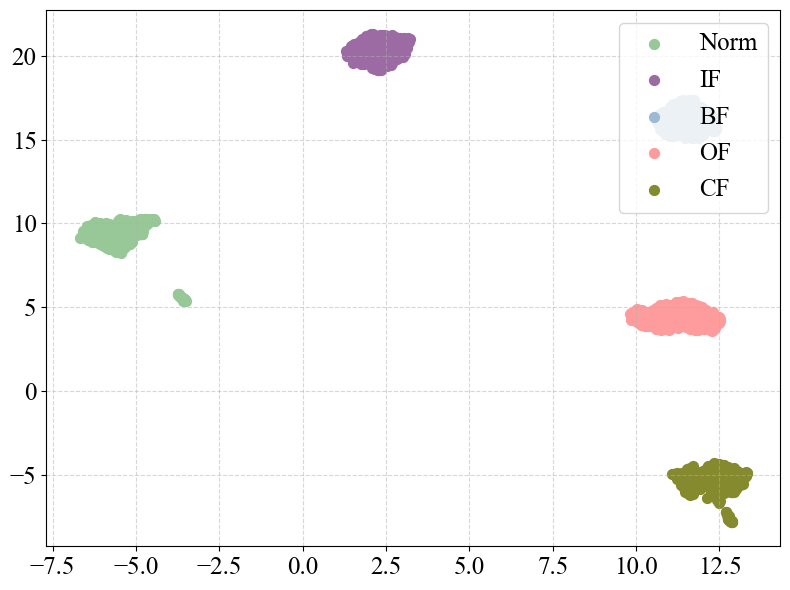

In [9]:
test_signal = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_TSPN_feature(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/tspn')

## Resnet

### import model

In [10]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_Resnet_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/resnet.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Resnettime08-21-02-47_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [11]:
def get_Resnet_signal(model, signal):
    with torch.no_grad():
        x = rearrange(signal, 'b c n -> b n c')
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)

        x = model.avgpool(x)
        output = x.view(x.size(0), -1)
    return output

### resnet_umap

(1270, 4096, 2)
torch.Size([1270, 512])
(1270,)


d:\anaconda3\envs\phmbench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


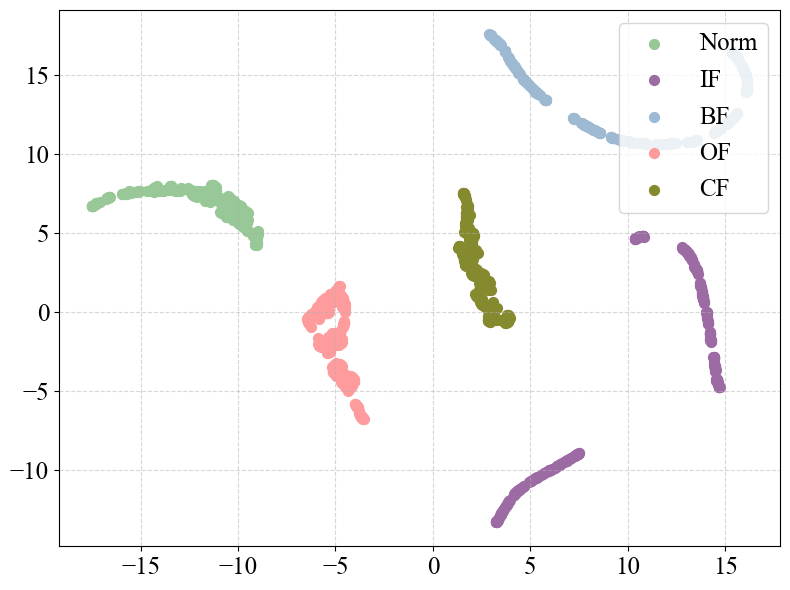

In [12]:
test_signal = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_Resnet_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/resnet')

## Sincnet

### import model

In [13]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_Sincnet.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/sincnet.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Sinc_net_mtime08-21-02-49_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [14]:
def get_sincnet_signal(model, signal):
    with torch.no_grad():
        x = rearrange(signal, 'b c n -> b n c')
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)

        x = model.avgpool(x)
        output = x.view(x.size(0), -1)
    return output

### sincnet_umap

(1270, 4096, 2)
torch.Size([1270, 512])
(1270,)


d:\anaconda3\envs\phmbench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


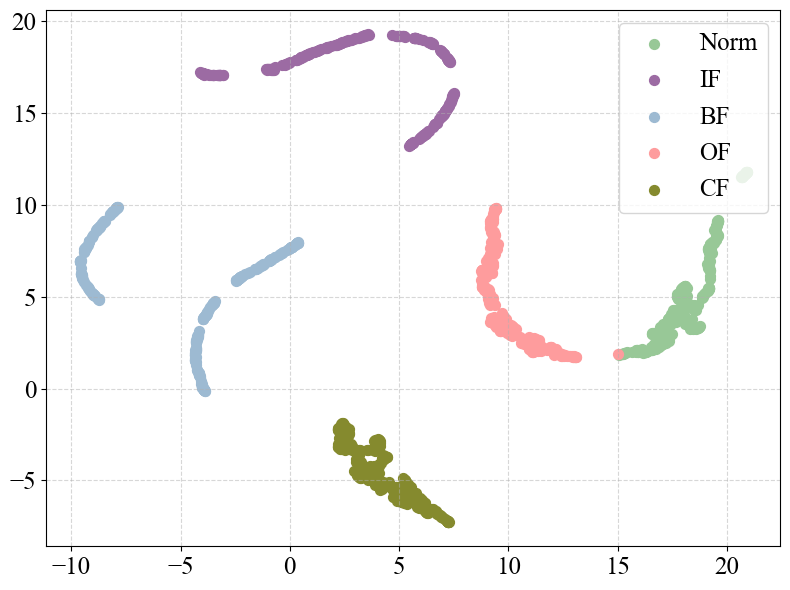

In [15]:
test_signal = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_sincnet_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/sincnet')

## MWACNN

### import model

In [16]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_MWA_CNN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/mwacnn.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_Huan_nettime08-21-02-52_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [17]:
def get_MWA_CNN_signal(model, signal):
    with torch.no_grad():
        input = rearrange(signal, 'b l c -> b c l')
        DMT_yl,DMT_yh = model.DWT0(input)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1)
            
        output = model.SConv1(output)
        DMT_yl,DMT_yh = model.DWT1(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1)
        output = model.dropout1(output)
        output = model.cSE1(output)
            
        output = model.SConv2(output)
        DMT_yl,DMT_yh = model.DWT2(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1) 
        output = model.dropout2(output)
        output = model.cSE2(output)
            
        output = model.SConv3(output)
        DMT_yl,DMT_yh = model.DWT3(output)
        output = torch.cat([DMT_yl,DMT_yh[0]], dim=1) 
        output = model.dropout3(output)
        output = model.cSE3(output)
            
        output = model.SConv6(output)
        output = model.avg_pool(output)
        output = output.view(output.size(0), -1)
    return output

### mwacnn_umap

(1270, 4096, 2)
torch.Size([1270, 96])
(1270,)


d:\anaconda3\envs\phmbench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


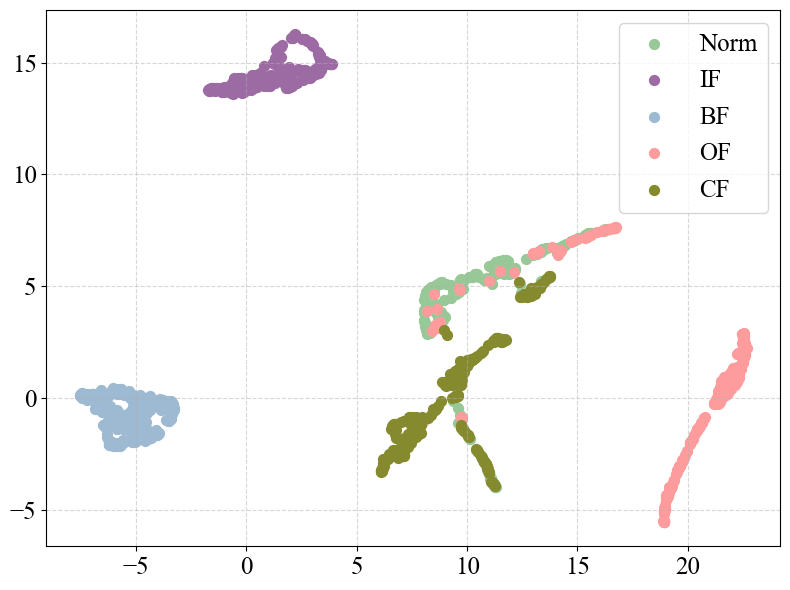

In [18]:
test_signal = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_MWA_CNN_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/mwacnn')

## MCN

### import model

In [19]:
import argparse
from model_collection.Resnet import ResNet, BasicBlock
from model_collection.Sincnet import Sincnet,Sinc_net_m
from model_collection.WKN import WKN,WKN_m
from model_collection.EELM import Dong_ELM
from model_collection.MWA_CNN import A_cSE,Huan_net
from model_collection.TFN.Models.TFN import TFN_Morlet
from model_collection.MCN.models import MCN_GFK, MultiChannel_MCN_GFK
from model_collection.MCN.models import MCN_WFK,MultiChannel_MCN_WFK
from trainer.trainer_basic import Basic_plmodel
from einops import rearrange
import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

parser = argparse.ArgumentParser(description='comparison model')
parser.add_argument('--config_dir', type=str, default='configs/a_010_SEU/config_MCN_basic.yaml',help='The directory of the configuration file')

# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
ff = np.arange(0, args.in_dim//2 + 1) / args.in_dim//2 + 1
MODEL_DICT = {
            'Resnet': lambda args: ResNet(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'WKN_m': lambda args: WKN_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Sinc_net_m': lambda args: Sinc_net_m(BasicBlock, [2, 2, 2, 2], in_channel=args.in_channels, num_class=args.num_classes),
            'Huan_net': lambda args: Huan_net(input_size=args.in_channels, num_class=args.num_classes),
            'TFN_Morlet': lambda args: TFN_Morlet(in_channels=args.in_channels, out_channels=args.num_classes),
            'MCN_GFK': lambda args: MultiChannel_MCN_GFK(ff=ff, in_channels=args.in_channels, num_MFKs=8, num_classes=args.num_classes)
        }

model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_seu/mcn.ckpt")
model.load_state_dict(state_dict['state_dict'])
# print(model)


Running experiment: model_MCN_GFKtime08-21-02-53_datasetSEU_010_Basic_it0


<All keys matched successfully>

### 计算特征函数

In [20]:
def get_mcn_signal(model, signal):
    with torch.no_grad():
        out = torch.cat([model.features[i](signal[:, :, i].unsqueeze(1)) for i in range(len(model.features))], dim=1)
        out = model.conv(out.real)
        out = model.AdpAvgpool(out)
        out = model.flatten(out)
        out = model.fc(out)
    return out

### mcn_umap

(1270, 4096, 2)
torch.Size([1270, 5])
(1270,)


d:\anaconda3\envs\phmbench\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


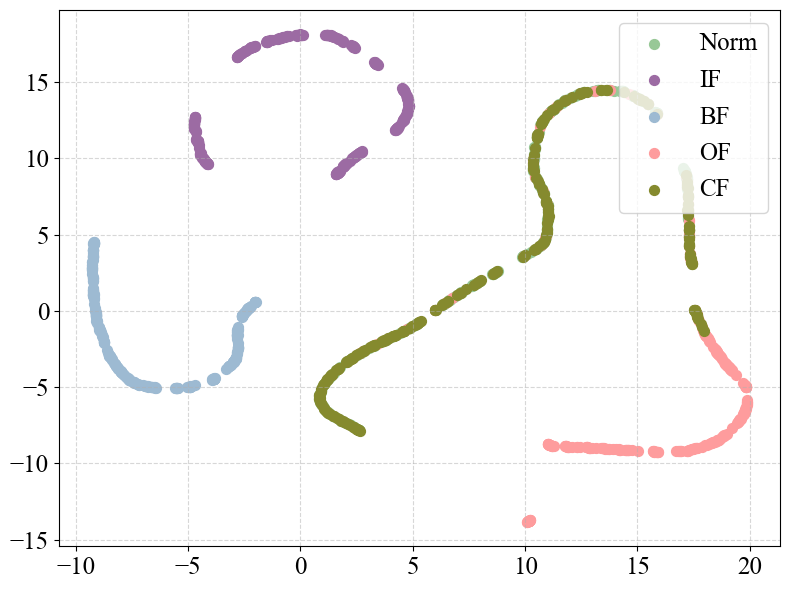

In [21]:
test_signal = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_data.npy")
print(test_signal.shape)
test_data = torch.from_numpy(test_signal).float().cuda()  # 新增：转为Tensor并放到GPU
feature = get_mcn_signal(model.network.cuda(), test_data)
print(feature.shape)
y_label = np.load("E:/dateset/generate/SEU_bearing/SEU_bearing_20Hz_2_label.npy")
print(y_label.shape)
fault_type_list = ['Norm', 'IF', 'BF', 'OF', 'CF']
plot_Umap(feature, y_label, fault_type_list, 'seu/feature/mcn')